
# 01 — Loudspeaker System: Free Air, Sealed Box, and Monopole Radiation

This notebook builds the model progressively through three experiments:

1. **Driver in free air**
2. **Driver in a sealed box, without a radiation model**
3. **Driver in the same sealed box, with monopole radiation**

The goal is not only to generate curves, but to identify **which quantities change when each physical component is added**.

The three models are solved with the same **1 V input**, so their responses can be compared directly.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")

from src.components.driver import Driver
from src.components.enclosure import SealedBox
from src.components.radiation import MonopoleRadiation
from src.system import LoudspeakerSystem
from src.diagrams.rendering import render_block_diagram
from src.utils import magnitude_to_db

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True



## Driver and simulation setup

All internal model parameters are expressed in SI units.

The driver parameters below are the values currently used for the Dayton driver model. The frequency grid extends from 10 Hz to 1 kHz; this notebook is focused on the low-frequency lumped-parameter regime rather than cone breakup or detailed high-frequency radiation.


In [2]:
# driver = Driver(
#     Re=3.4,          # ohm
#     Le=1.43e-3,      # H
#     Fs=35.7,         # Hz
#     Qms=6.62,
#     Qes=0.36,
#     Mms=39.5e-3,     # kg
#     Cms=0.5e-3,      # m/N
#     Sd=124.7e-4,     # m^2
#     Bl=9.15,         # T*m = N/A,
#     Xmax=6e-3        # mm
# )

driver = Driver.from_thiele_small(
    Re=3.4,
    Le=1.43e-3,

    Fs=35.7,
    Qms=6.620,
    Qes=0.360,

    Vas=12.10e-3,      # 12.10 L
    Sd=124.7e-4,       # 124.7 cm²

    Xmax=6e-3,         # 6 mm
    Pe=100,
)

freqs = np.logspace(1, 3, 1200)
voltage = 1.0

print(f"Fs (datasheet):              {driver.Fs:.2f} Hz")
print(f"Fs from Mms and Cms:         {driver.Fs_from_mass_compliance:.2f} Hz")
print(f"Qts:                         {driver.Qts:.3f}")
print(f"Rms:                         {driver.Rms:.3f} N·s/m")
print(f"Vas:                         {1e3 * driver.Vas():.2f} L")


Fs (datasheet):              35.70 Hz
Fs from Mms and Cms:         35.70 Hz
Qts:                         0.341
Rms:                         1.228 N·s/m
Vas:                         12.10 L



# Experiment 1 — Driver in free air

The first model contains only the driver's electrical and mechanical parameters.

The coupled electromechanical system is

$Z_\mathrm{in} = Z_e + \frac{(Bl)^2}{Z_m}$

with

$Z_e = R_e + j\omega L_e$

and

$Z_m = R_{ms} +j\omega M_{ms} +\frac{1}{j\omega C_{ms}}$

This is the baseline model. Its most obvious signature is the electrical impedance peak around the free-air resonance \(F_s\).


In [3]:
free_air = LoudspeakerSystem(driver=driver)
fa_response = free_air.solve(freqs, voltage=voltage)
fa_chars = free_air.characteristics()

print("FREE-AIR CHARACTERISTICS")
print(f"Resonance frequency: {fa_chars.resonance_frequency:.2f} Hz")
print(f"Mechanical Q:        {fa_chars.mechanical_q:.3f}")
print(f"Electrical Q:        {fa_chars.electrical_q:.3f}")
print(f"Total Q:             {fa_chars.total_q:.3f}")
print(f"Effective compliance:{fa_chars.effective_compliance:.6e} m/N")


FREE-AIR CHARACTERISTICS
Resonance frequency: 35.70 Hz
Mechanical Q:        6.620
Electrical Q:        0.360
Total Q:             0.341
Effective compliance:5.485535e-04 m/N


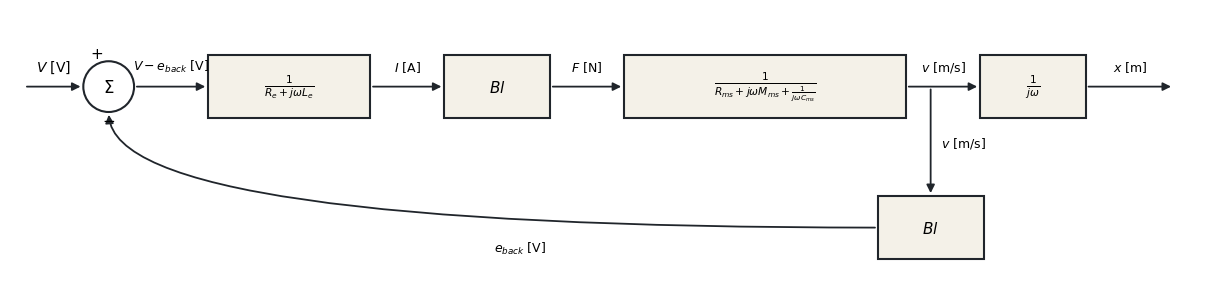

In [4]:
figure, _ = render_block_diagram(
        free_air.block_diagram(output='displacement', distance=1.0)
    )

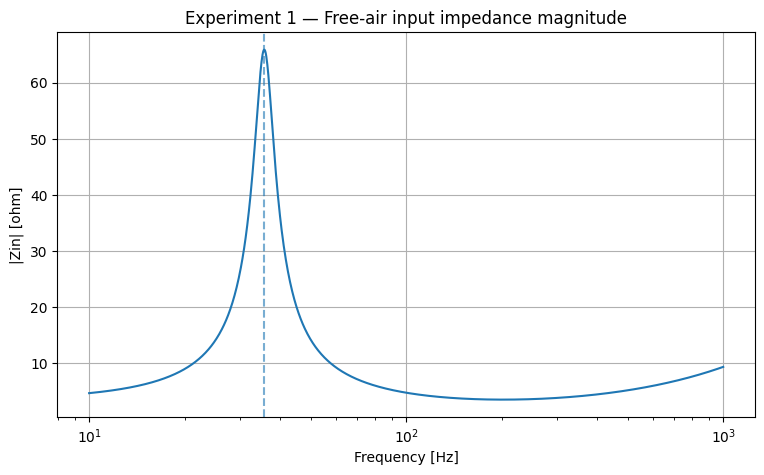

In [5]:

plt.figure()
plt.semilogx(freqs, np.abs(fa_response.input_impedance))
plt.axvline(fa_chars.resonance_frequency, linestyle="--", alpha=0.6)
plt.xlabel("Frequency [Hz]")
plt.ylabel("|Zin| [ohm]")
plt.title("Experiment 1 — Free-air input impedance magnitude")
plt.show()


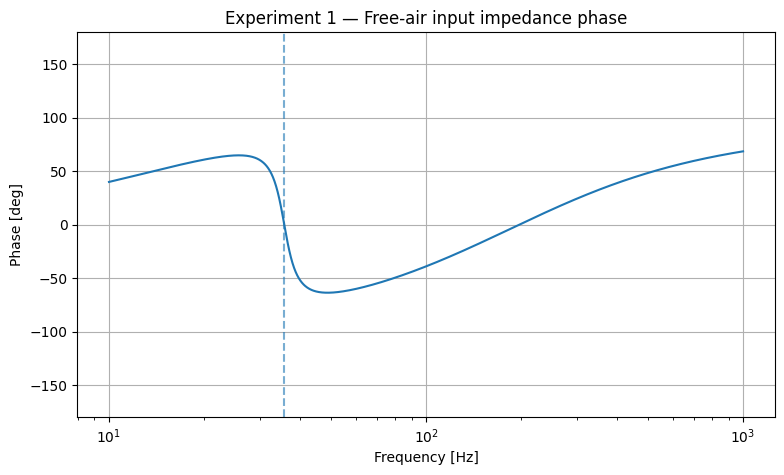

In [6]:

plt.figure()
plt.semilogx(freqs, np.angle(fa_response.input_impedance, deg=True))
plt.axvline(fa_chars.resonance_frequency, linestyle="--", alpha=0.6)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [deg]")
plt.ylim(-180, 180)
plt.title("Experiment 1 — Free-air input impedance phase")
plt.show()



### Discussion

The free-air resonance appears as a strong peak in input impedance. Around resonance the driver's mechanical velocity is large, increasing the back-EMF \(Bl\,u\), which is reflected into the electrical domain as an additional impedance.

Below resonance, suspension compliance dominates the mechanical reactance. Above resonance, moving mass increasingly dominates it; at still higher frequencies the electrical voice-coil inductance \(L_e\) also becomes important.



# Experiment 2 — Driver in a sealed box, no radiation model

A sealed enclosure adds an acoustic compliance

$C_{ab} = \frac{V_b}{\rho_0 c^2}$

with acoustic impedance

$Z_{a,\mathrm{box}} = \frac{1}{j\omega C_{ab}}$

The acoustic load is reflected into the mechanical domain through the piston area:

$Z_{m,\mathrm{box}} = S_d^2 Z_{a,\mathrm{box}}$

The enclosed air therefore adds another spring to the system. We expect:

- lower effective compliance;
- higher resonance frequency;
- modified system Q;
- changes in current, velocity, displacement and volume velocity around the resonance region.


In [7]:
box = SealedBox(
    volume=3.68e-3,
)

sealed = LoudspeakerSystem(
    driver=driver,
    enclosure=box,
)

sealed_response = sealed.solve(freqs, voltage=voltage)
sealed_chars = sealed.characteristics()

print("SEALED-BOX CHARACTERISTICS")
print(f"Box volume:           {1e3 * box.volume:.2f} L")
print(f"Resonance frequency:  {sealed_chars.resonance_frequency:.2f} Hz")
print(f"Mechanical Q:         {sealed_chars.mechanical_q:.3f}")
print(f"Electrical Q:         {sealed_chars.electrical_q:.3f}")
print(f"Total Q:              {sealed_chars.total_q:.3f}")
print(f"Effective compliance: {sealed_chars.effective_compliance:.6e} m/N")

SEALED-BOX CHARACTERISTICS
Box volume:           3.68 L
Resonance frequency:  73.93 Hz
Mechanical Q:         13.708
Electrical Q:         0.745
Total Q:              0.707
Effective compliance: 1.279263e-04 m/N


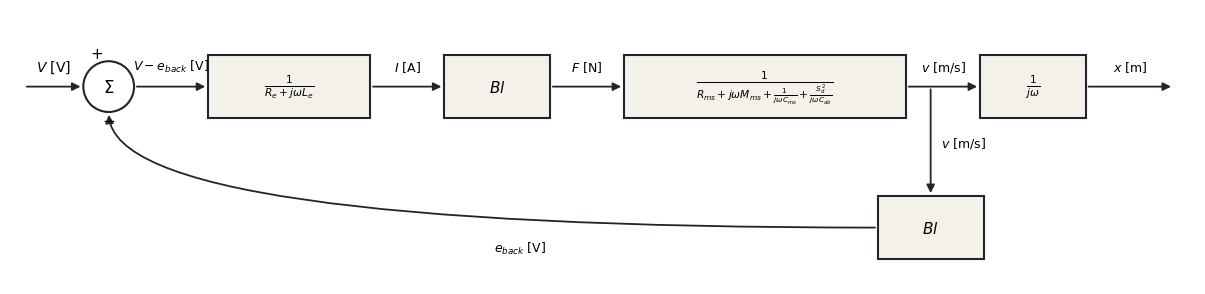

In [8]:
figure, _ = render_block_diagram(
        sealed.block_diagram(output='displacement', distance=1.0)
    )


## What changes when the sealed box is added?

The following plots compare the free-air and sealed-box systems directly. Quantities that are intrinsically driver-only, such as the electrical impedance `Ze`, are not repeated because they do not change when the enclosure is added.


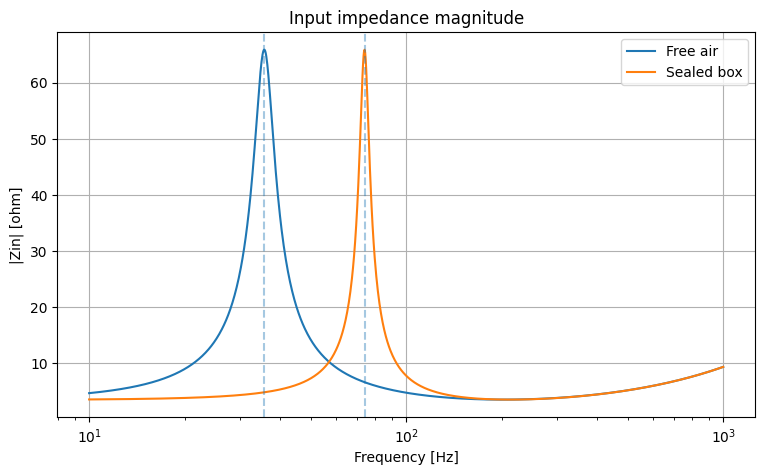

In [9]:

plt.figure()
plt.semilogx(freqs, np.abs(fa_response.input_impedance), label="Free air")
plt.semilogx(freqs, np.abs(sealed_response.input_impedance), label="Sealed box")
plt.axvline(fa_chars.resonance_frequency, linestyle="--", alpha=0.4)
plt.axvline(sealed_chars.resonance_frequency, linestyle="--", alpha=0.4)
plt.xlabel("Frequency [Hz]")
plt.ylabel("|Zin| [ohm]")
plt.title("Input impedance magnitude")
plt.legend()
plt.show()


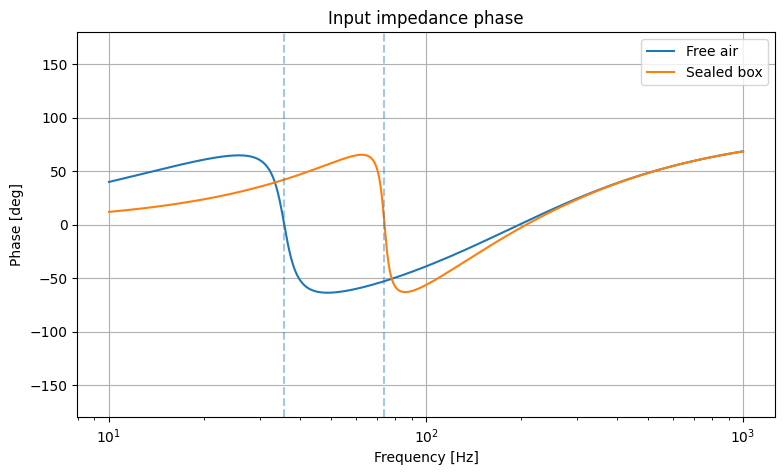

In [10]:

plt.figure()
plt.semilogx(
    freqs,
    np.angle(fa_response.input_impedance, deg=True),
    label="Free air",
)
plt.semilogx(
    freqs,
    np.angle(sealed_response.input_impedance, deg=True),
    label="Sealed box",
)
plt.axvline(fa_chars.resonance_frequency, linestyle="--", alpha=0.4)
plt.axvline(sealed_chars.resonance_frequency, linestyle="--", alpha=0.4)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [deg]")
plt.ylim(-180, 180)
plt.title("Input impedance phase")
plt.legend()
plt.show()



The impedance peak shifts upward because the trapped air reduces the effective compliance. Since the mechanical system is coupled back into the electrical circuit through \(Bl\), the enclosure is visible electrically even though the box itself contains no electrical component.


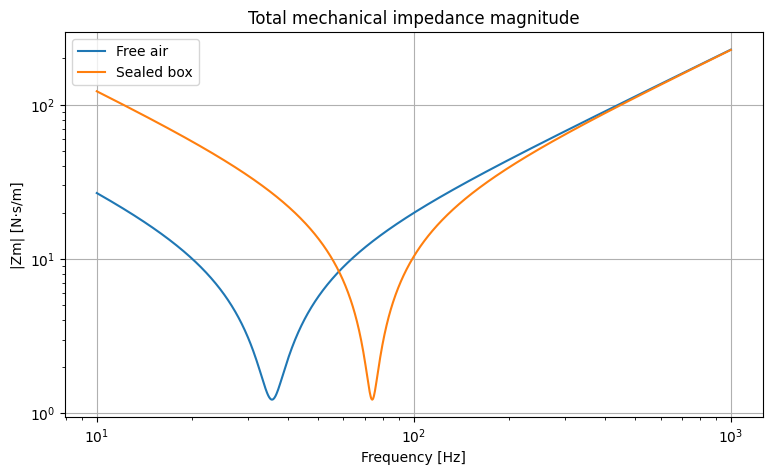

In [11]:

plt.figure()
plt.loglog(freqs, np.abs(fa_response.mechanical_impedance), label="Free air")
plt.loglog(freqs, np.abs(sealed_response.mechanical_impedance), label="Sealed box")
plt.xlabel("Frequency [Hz]")
plt.ylabel("|Zm| [N·s/m]")
plt.title("Total mechanical impedance magnitude")
plt.legend()
plt.show()


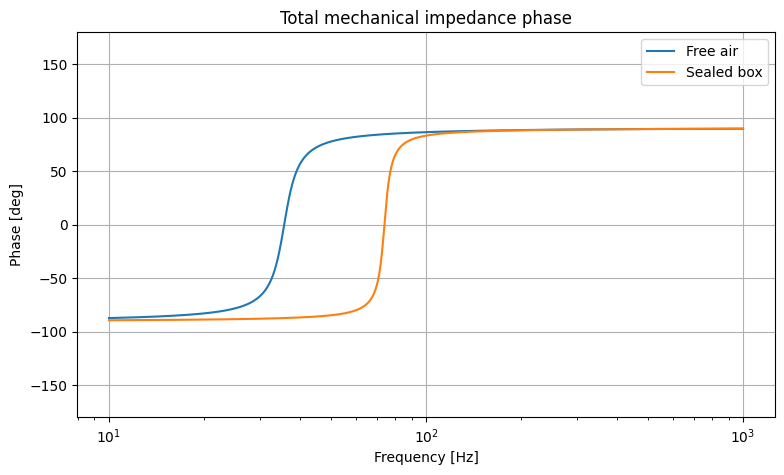

In [12]:

plt.figure()
plt.semilogx(
    freqs,
    np.angle(fa_response.mechanical_impedance, deg=True),
    label="Free air",
)
plt.semilogx(
    freqs,
    np.angle(sealed_response.mechanical_impedance, deg=True),
    label="Sealed box",
)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [deg]")
plt.ylim(-180, 180)
plt.title("Total mechanical impedance phase")
plt.legend()
plt.show()



The largest direct physical change is in mechanical impedance. At low frequency the sealed-box air spring adds substantial stiffness, so the reactive balance between compliance and mass occurs at a higher frequency.


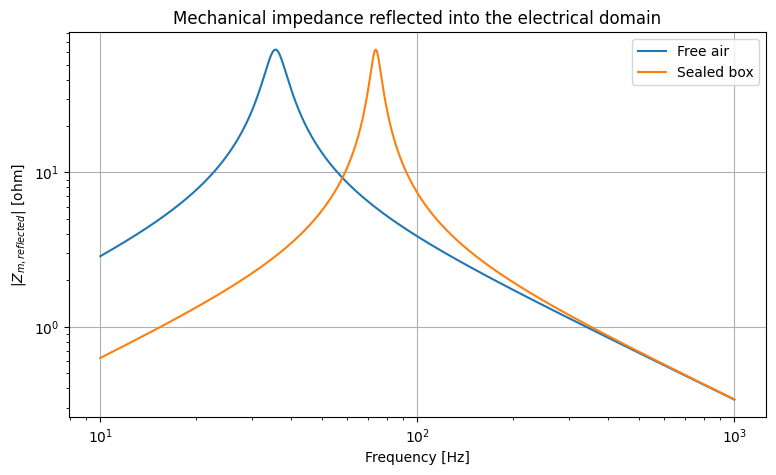

In [13]:

plt.figure()
plt.loglog(freqs, np.abs(fa_response.reflected_mechanical_impedance), label="Free air")
plt.loglog(freqs, np.abs(sealed_response.reflected_mechanical_impedance), label="Sealed box")
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|Z_{m,reflected}|$ [ohm]")
plt.title("Mechanical impedance reflected into the electrical domain")
plt.legend()
plt.show()



The reflected term

$Z_\mathrm{ref} = \frac{(Bl)^2}{Z_m}$

shows explicitly how the changed mechanical load returns to the electrical input. This is the bridge between the previous mechanical-impedance plot and the shifted electrical impedance peak.


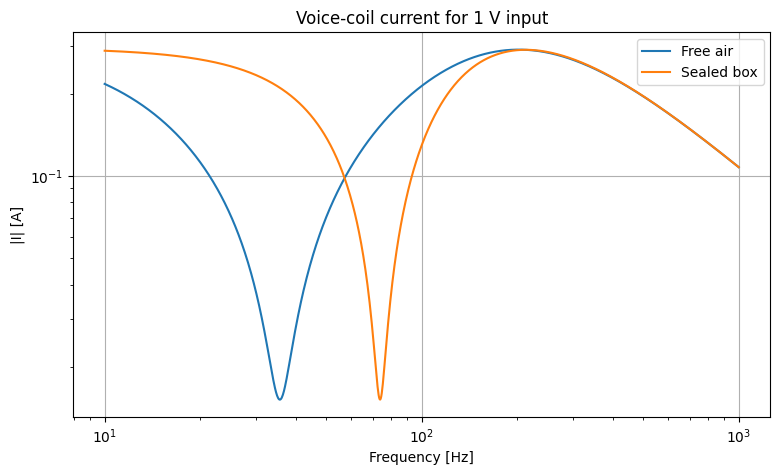

In [14]:

plt.figure()
plt.loglog(freqs, np.abs(fa_response.current), label="Free air")
plt.loglog(freqs, np.abs(sealed_response.current), label="Sealed box")
plt.xlabel("Frequency [Hz]")
plt.ylabel("|I| [A]")
plt.title("Voice-coil current for 1 V input")
plt.legend()
plt.show()



Current changes because the total electrical input impedance changes. The force curve is not plotted separately because `F = Bl * I`; with constant `Bl`, it has exactly the same frequency dependence as current.


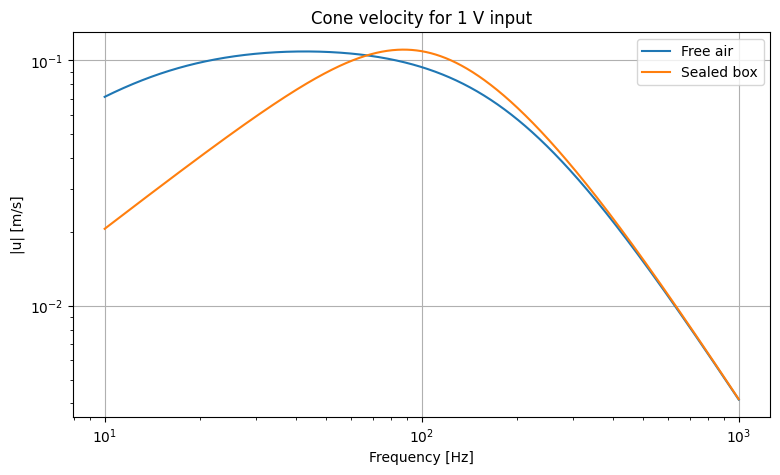

In [15]:

plt.figure()
plt.loglog(freqs, np.abs(fa_response.velocity), label="Free air")
plt.loglog(freqs, np.abs(sealed_response.velocity), label="Sealed box")
plt.xlabel("Frequency [Hz]")
plt.ylabel("|u| [m/s]")
plt.title("Cone velocity for 1 V input")
plt.legend()
plt.show()


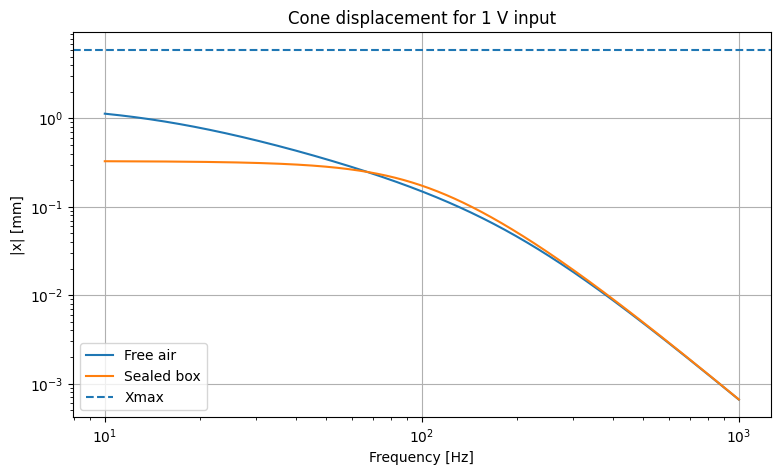

In [16]:

plt.figure()
plt.loglog(freqs, 1e3 * np.abs(fa_response.displacement), label="Free air")
plt.loglog(freqs, 1e3 * np.abs(sealed_response.displacement), label="Sealed box")

if driver.Xmax is not None:
    plt.axhline(1e3 * driver.Xmax, linestyle="--", label="Xmax")

plt.xlabel("Frequency [Hz]")
plt.ylabel("|x| [mm]")
plt.title("Cone displacement for 1 V input")
plt.legend()
plt.show()



Velocity and displacement show the practical consequence of the extra air spring. The enclosure suppresses very-low-frequency motion and shifts the velocity resonance upward.

Since

$x = \frac{u}{j\omega}$,

displacement emphasizes the low-frequency operating region even more strongly. This curve will later be used together with \(X_\mathrm{max}\) to define the safe operating envelope.


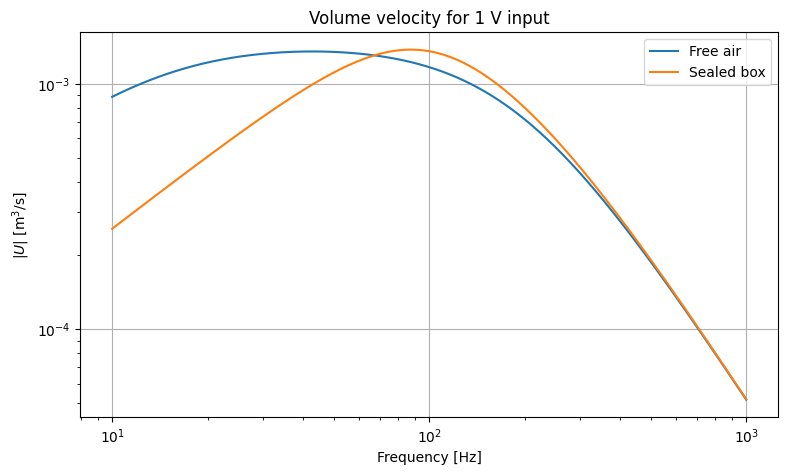

In [17]:

plt.figure()
plt.loglog(freqs, np.abs(fa_response.volume_velocity), label="Free air")
plt.loglog(freqs, np.abs(sealed_response.volume_velocity), label="Sealed box")
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$|U|$ [m$^3$/s]")
plt.title("Volume velocity for 1 V input")
plt.legend()
plt.show()



Volume velocity is

$U = S_d u$

Because \(S_d\) is constant, this plot has the same shape as cone velocity but is retained because \(U\) is the quantity that couples naturally to the acoustic radiation model.

The back-EMF curve is also omitted as a separate plot because $e_\mathrm{back}=Bl\,u$, so it has the same frequency dependence as velocity.



# Analytical sealed-box transfer function

For the ideal low-frequency sealed-box model,

$ H(s) = \frac{s^2} {s^2+\frac{\omega_c}{Q_{tc}}s+\omega_c^2}$

This is the normalized second-order high-pass response of the sealed system. It is useful as a separate analytical description because it can be compared directly with a WinISD transfer-function export.


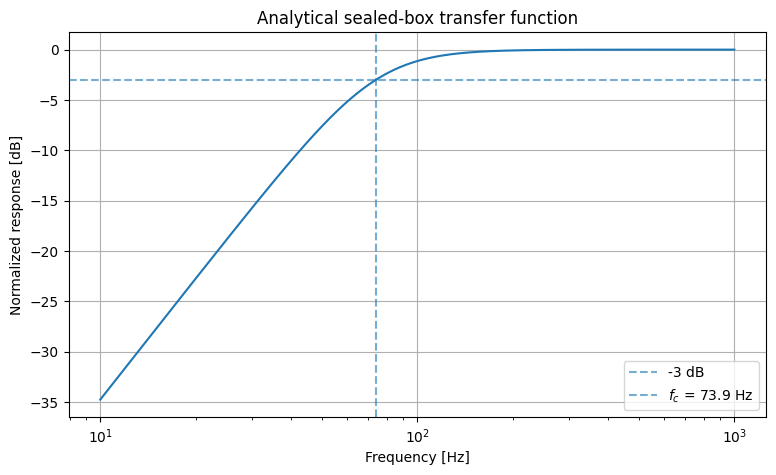

In [18]:

H_sealed = sealed.analytical_transfer_function(freqs)
H_sealed_db = magnitude_to_db(H_sealed)

plt.figure()
plt.semilogx(freqs, H_sealed_db)
plt.axhline(-3, linestyle="--", alpha=0.6, label="-3 dB")
plt.axvline(
    sealed_chars.resonance_frequency,
    linestyle="--",
    alpha=0.6,
    label=fr"$f_c$ = {sealed_chars.resonance_frequency:.1f} Hz",
)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized response [dB]")
plt.title("Analytical sealed-box transfer function")
plt.legend()
plt.show()



If $Q_{tc}$ is close to $1/\sqrt{2}$, the response at $f_c$ should lie close to -3 dB. More generally, the exact value at $f_c is controlled by $Q_{tc}$.

A WinISD curve can be overlaid on this figure later. Agreement here validates the closed-box alignment equations independently of the monopole radiation approximation.



# Experiment 3 — Sealed box with monopole radiation

The third model uses exactly the same electromechanical sealed-box system and adds an **output radiation model**.

For the current half-space monopole approximation,

$p(r,\omega) = \frac{j\omega\rho_0 U}{2\pi r}e^{-jkr}$

At this stage radiation is **one-way**: cone volume velocity generates pressure, but radiation impedance is not fed back into the mechanical load.

That gives us an important regression test:

> adding `MonopoleRadiation` should create pressure, but should not change impedance, current, velocity, displacement, or volume velocity.


In [19]:

monopole = MonopoleRadiation()

sealed_monopole = LoudspeakerSystem(
    driver=driver,
    enclosure=box,
    radiation=monopole,
)

mono_response = sealed_monopole.solve(
    freqs,
    voltage=voltage,
    distance=1.0,
)

mono_chars = sealed_monopole.characteristics()

print("SEALED + MONOPOLE CHARACTERISTICS")
print(f"Resonance frequency: {mono_chars.resonance_frequency:.2f} Hz")
print(f"Qtc:                 {mono_chars.total_q:.3f}")
print(f"Pressure available:  {mono_response.pressure is not None}")


SEALED + MONOPOLE CHARACTERISTICS
Resonance frequency: 73.93 Hz
Qtc:                 0.707
Pressure available:  True


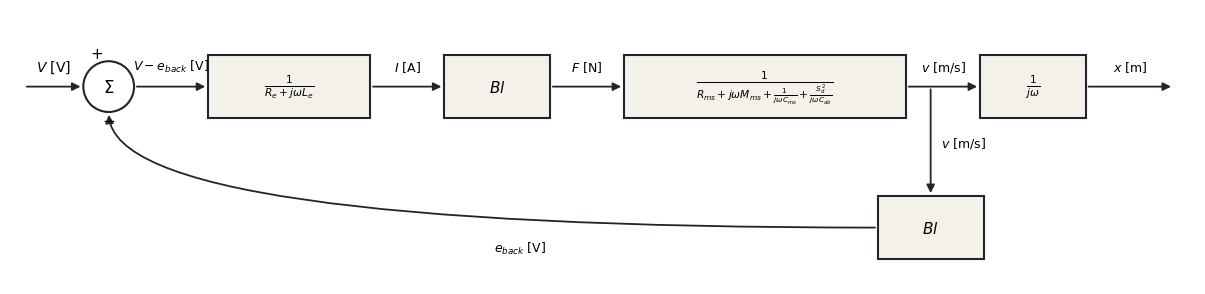

In [20]:
figure, _ = render_block_diagram(
        sealed_monopole.block_diagram()
    )

In [21]:

unchanged_fields = [
    "input_impedance",
    "current",
    "velocity",
    "displacement",
    "volume_velocity",
    "mechanical_impedance",
]

for field in unchanged_fields:
    a = getattr(sealed_response, field)
    b = getattr(mono_response, field)
    np.testing.assert_allclose(a, b)

print("Regression check passed:")
print("Monopole radiation does not alter the electromechanical solution.")


Regression check passed:
Monopole radiation does not alter the electromechanical solution.



Because the regression check confirms that nothing upstream changes, reproducing all sealed-box electromechanical plots would only draw identical curves on top of each other. The **new observable introduced by Experiment 3 is pressure**.


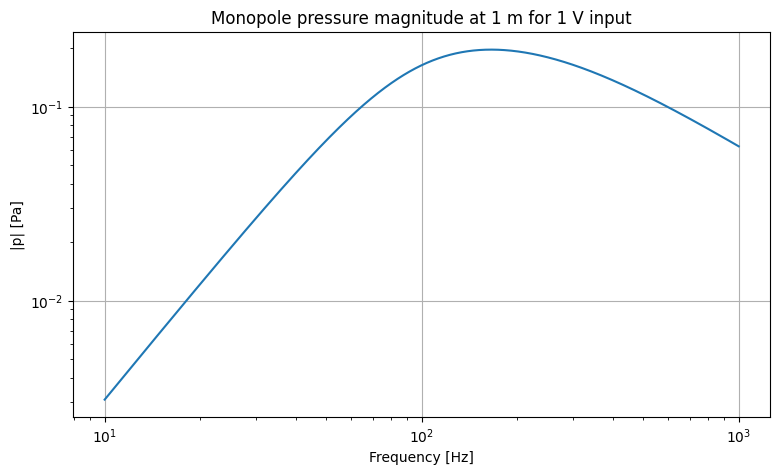

In [22]:

plt.figure()
plt.loglog(freqs, np.abs(mono_response.pressure))
plt.xlabel("Frequency [Hz]")
plt.ylabel("|p| [Pa]")
plt.title("Monopole pressure magnitude at 1 m for 1 V input")
plt.show()


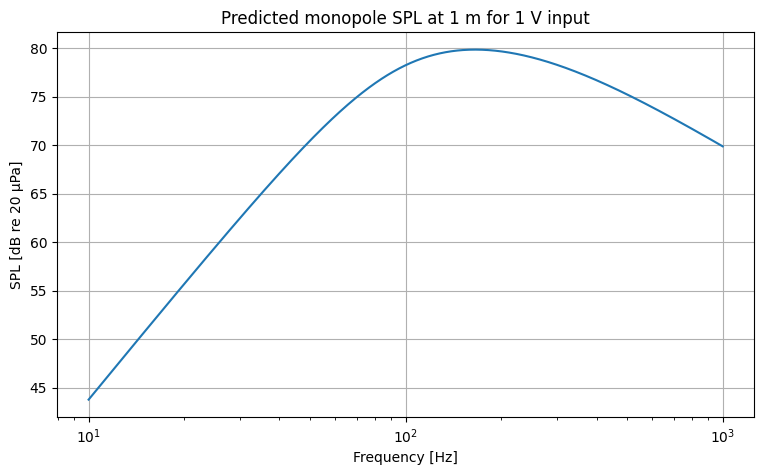

In [23]:

plt.figure()
plt.semilogx(freqs, mono_response.spl)
plt.xlabel("Frequency [Hz]")
plt.ylabel("SPL [dB re 20 µPa]")
plt.title("Predicted monopole SPL at 1 m for 1 V input")
plt.show()



Pressure is not proportional to displacement directly. The monopole model gives

$p \propto j\omega U$

so radiation contributes one additional factor of frequency. This is why a large low-frequency cone excursion does not necessarily imply a large radiated sound pressure.


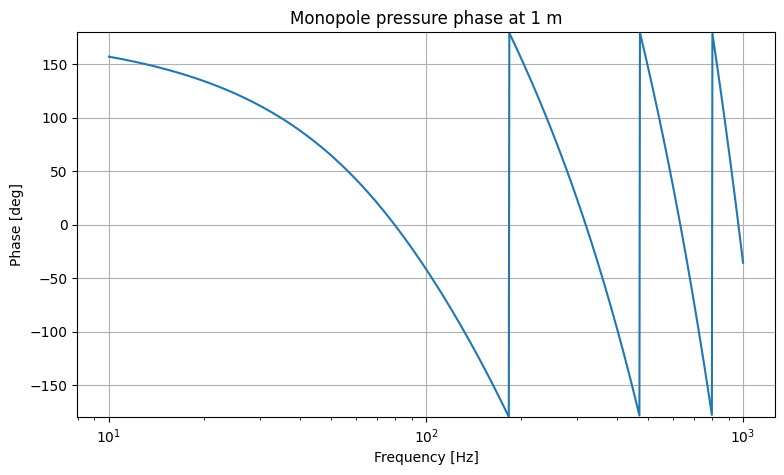

In [24]:

plt.figure()
plt.semilogx(freqs, np.angle(mono_response.pressure, deg=True))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [deg]")
plt.ylim(-180, 180)
plt.title("Monopole pressure phase at 1 m")
plt.show()


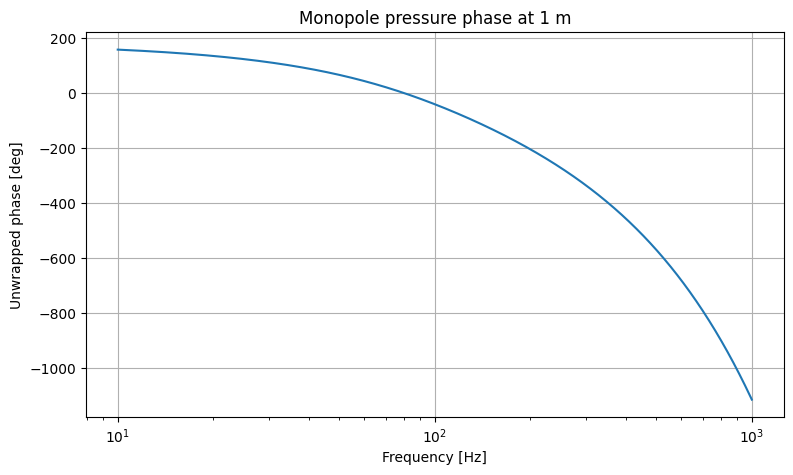

In [25]:
phase = np.unwrap(np.angle(mono_response.pressure))
phase_deg = np.degrees(phase)

plt.semilogx(freqs, phase_deg)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Unwrapped phase [deg]")
plt.title("Monopole pressure phase at 1 m")
plt.show()


The pressure phase contains both the source dynamics and the propagation phase term

$e^{-jkr}$

As distance or frequency increases, propagation delay contributes an increasingly large phase rotation.



# Analytical alignment vs. full monopole acoustic response

The analytical sealed-box transfer function isolates the ideal second-order box alignment.

The monopole pressure response instead contains the complete chain

$
V
\rightarrow I
\rightarrow F
\rightarrow u
\rightarrow U
\rightarrow p,
$
including voice-coil inductance and the radiation factor \(j\omega\).

To compare their shapes, normalize the pressure response to a reference region above \(f_c\).


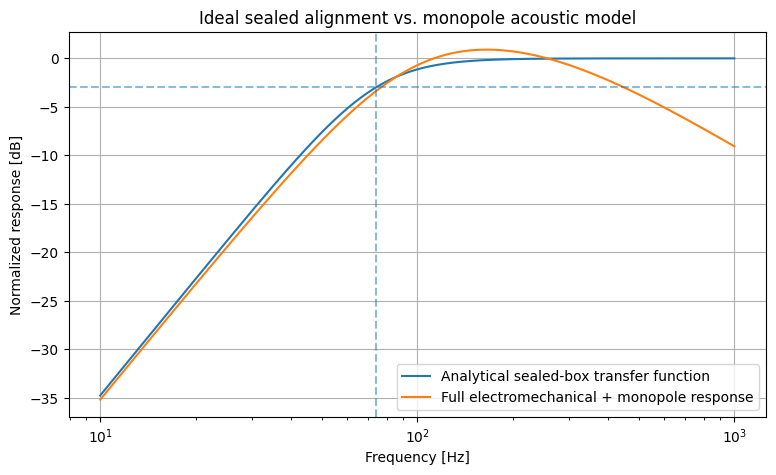

In [26]:

fc = sealed_chars.resonance_frequency

reference_mask = (
    (freqs >= 3 * fc)
    & (freqs <= 4 * fc)
)

pressure_reference = np.mean(
    np.abs(mono_response.pressure[reference_mask])
)

pressure_normalized_db = magnitude_to_db(
    mono_response.pressure,
    reference=pressure_reference,
)

plt.figure()
plt.semilogx(
    freqs,
    H_sealed_db,
    label="Analytical sealed-box transfer function",
)
plt.semilogx(
    freqs,
    pressure_normalized_db,
    label="Full electromechanical + monopole response",
)
plt.axhline(-3, linestyle="--", alpha=0.5)
plt.axvline(fc, linestyle="--", alpha=0.5)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized response [dB]")
plt.title("Ideal sealed alignment vs. monopole acoustic model")
plt.legend()
plt.show()



### Discussion

At low frequency the two curves should show the same basic sealed-box high-pass behavior because both are governed by the same mass–spring–damper resonance.

They need not remain identical at higher frequency:

- the analytical transfer function is an ideal second-order alignment model;
- the full numerical curve includes the driver's electrical and mechanical dynamics;
- voice-coil inductance increasingly matters as frequency rises;
- monopole pressure contains the additional \(j\omega\) radiation factor.

This comparison is therefore useful precisely because the two curves answer slightly different questions.



# Summary of the three experiments

### 1. Free air

The driver's own suspension defines the low-frequency resonance. The resonance appears in both the mechanical solution and the electrical input impedance through electromechanical coupling.

### 2. Sealed box

The trapped air adds compliance loading. Effective compliance decreases, resonance shifts upward, and the changed mechanical impedance modifies electrical impedance, current, cone velocity, displacement and volume velocity.

### 3. Sealed box + monopole radiation

The current radiation model is output-only. It leaves the complete electromechanical solution unchanged and adds a prediction of acoustic pressure and SPL.

This separation is intentional: it gives a clean baseline before radiation **loading** is introduced later.


# Annex: Comparison of Transfer-function diagrams



These diagrams use the conventional signal-flow notation:



- **arrows carry physical quantities** such as $V$, $I$, $F$, $v$, $U$, and $p$;

- **rectangular blocks contain transfer functions** that map one quantity to the next;

- the summing junction forms $V-e_\mathrm{back}$;

- the lower branch closes the electromechanical feedback loop through $e_\mathrm{back}=Bl\,v$.



The system composition determines which transfer blocks appear. Free air uses only the driver mechanical admittance. Adding the sealed box adds its reflected acoustic compliance to that mechanical denominator. Adding the output-only monopole appends



$$

U=S_dv

$$



and the complete pressure transfer function



$$

\frac{p(r,\omega)}{U}=\frac{j\omega\rho_0}{2\pi r}e^{-jkr}.

$$



The radiation expression is shown directly rather than hidden behind an abbreviated name.


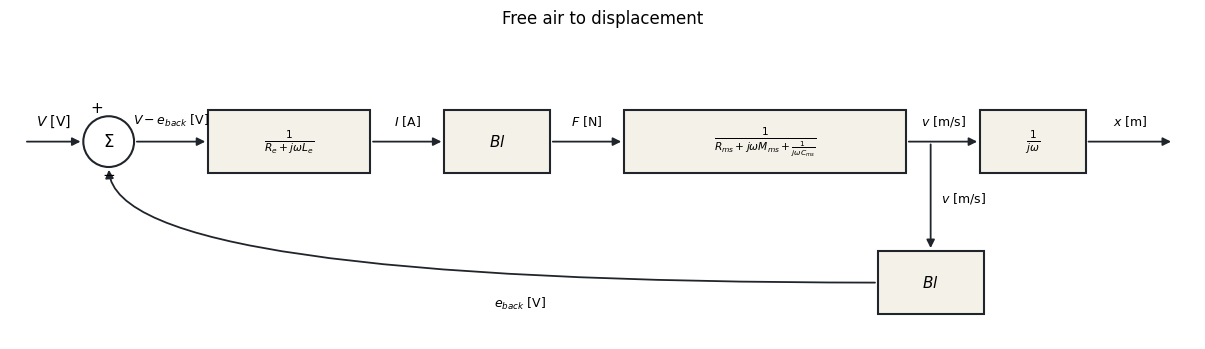

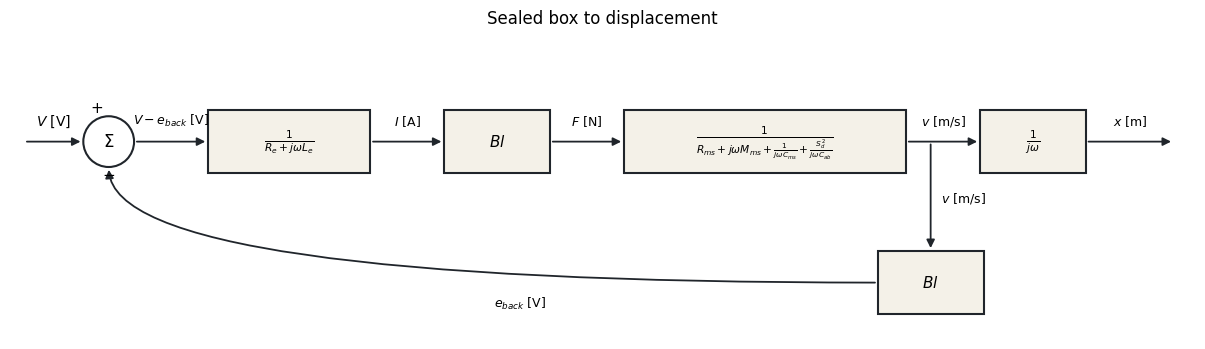

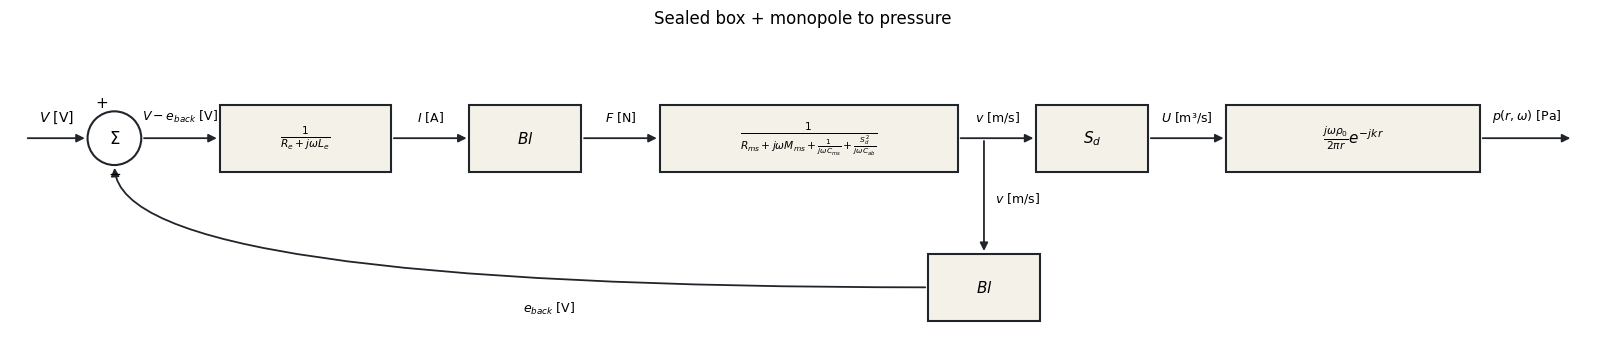

In [27]:
diagram_cases = (

    ("Free air to displacement", free_air, "displacement"),

    ("Sealed box to displacement", sealed, "displacement"),

    ("Sealed box + monopole to pressure", sealed_monopole, "pressure"),

)



for title, model, output in diagram_cases:

    figure, _ = render_block_diagram(

        model.block_diagram(output=output)

    )

    figure.suptitle(title)

    plt.show()
